In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load processed dataset
df = pd.read_csv("patient_features_final.csv")

# Inspect dataset
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())

df.head()


Shape: (15116, 21)

Missing values per column:
patient_id                      0
encounter_id                    0
icd_prefix3_unique_str          0
n_icd_prefix3                   0
encounter_start_dt              0
encounter_end_dt                0
encounter_duration_days         0
encounter_setting               0
encounter_medical_service       0
adt_event_types_seq_str         0
adt_event_times_seq_str         0
PATIENT_BIRTH_YEAR              4
PATIENT_SEX                     4
PATIENT_RACE_ETHNICITY          4
DECEASED_FLAG                   4
age                             4
med_order_nunique            2329
proc_codes_seq_str           1207
proc_descs_seq_str           1207
proc_times_seq_str           1207
proc_count                   1207
dtype: int64


,patient_id,encounter_id,icd_prefix3_unique_str,n_icd_prefix3,encounter_start_dt,encounter_end_dt,encounter_duration_days,encounter_setting,encounter_medical_service,adt_event_types_seq_str,...,PATIENT_BIRTH_YEAR,PATIENT_SEX,PATIENT_RACE_ETHNICITY,DECEASED_FLAG,age,med_order_nunique,proc_codes_seq_str,proc_descs_seq_str,proc_times_seq_str,proc_count
0,0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43e...,0cf2b96aa588db64f96239a66b9d8c640489f1959aa678...,"E11,E86,F31,I50,J44,N30",6,2022-11-19 00:00:00+00:00,2022-11-21 03:15:00+00:00,2.135417,Observation,Nursing - medical / surgical,Admission|Census|Census|Discharge,...,1948.0,Female,"White, non-Hispanic",1.0,77.0,11.0,99220|99225|99217,ZZ INIT OBSV CARE LVL III|ZZ SUBSEQ OBSV CARE ...,2022-11-19 00:00:00|2022-11-20 00:00:00|2022-1...,3.0
1,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,0d79127152552683ecf7ba4acd391eeaaa6e90cceffb39...,T18,1,2022-11-10 00:00:00+00:00,2022-11-12 02:55:00+00:00,2.121528,Observation,General surgery,Admission|Transfer Out|Transfer In|Transfer Ou...,...,1983.0,Male,Hispanic,0.0,42.0,12.0,99219|99285|00731|99999|43247|99226|99203|9999...,ZZ INIT OBSV CARE LVL II|EMERGENCY DEPT VISIT ...,2022-11-10 00:00:00|2022-11-10 00:00:00|2022-1...,10.0
2,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,dda0597e60a45d5ebc3e4e28db5df7bf3a55fd354823dd...,"B96,D69,E03,E78,E87,G70,I10,I11,I25,I27,I48,I5...",21,2023-02-07 00:00:00+00:00,2023-02-11 12:55:00+00:00,4.538194,Inpatient,Nursing - medical / surgical,Admission|Census|Census|Census|Census|Discharge,...,1934.0,Female,"White, non-Hispanic",0.0,91.0,13.0,99222|99232|99231|99239,INIT HOSP CARE MOD MDM 55 MIN|SUBSEQ HOSP CARE...,2023-02-08 00:00:00|2023-02-09 00:00:00|2023-0...,4.0
3,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,fa7ef0231ccd39aa1abedf74c1d4f4bf94fc6c01bcf421...,"E03,E66,I11,I48,I50,N30,N39,R77,R79,Z66,Z79,Z8...",13,2023-02-07 00:00:00+00:00,2023-02-07 06:24:00+00:00,0.266667,Outpatient,Emergency medicine,Admission|Discharge,...,1934.0,Female,"White, non-Hispanic",0.0,91.0,NaN,NaN,NaN,NaN,NaN
4,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,21de146f1dc5dceff5093a5202b9fe110b232c2fff563b...,"D72,E11,I10,K29,K92,R10,R79",7,2023-01-18 00:00:00+00:00,2023-01-22 03:55:00+00:00,4.163194,Inpatient,Nursing - medical / surgical,Admission|Census|Transfer Out|Transfer In|Tran...,...,1936.0,Female,"White, non-Hispanic",1.0,89.0,48.0,93010|99285|99222|99223|99232|99232|99999|9923...,ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS I...,2023-01-18 00:00:00|2023-01-18 00:00:00|2023-0...,19.0


In [ ]:
# Fill missing values
df["med_order_nunique"] = df["med_order_nunique"].fillna(0)
df["proc_count"] = df["proc_count"].fillna(0)
df["age"] = df["age"].fillna(df["age"].median())
df["PATIENT_SEX"] = df["PATIENT_SEX"].fillna("Unknown")
df["PATIENT_RACE_ETHNICITY"] = df["PATIENT_RACE_ETHNICITY"].fillna("Unknown")

# Confirm no NaNs remain in key model columns
df[["n_icd_prefix3","med_order_nunique","proc_count","age"]].isna().sum()


n_icd_prefix3        0
med_order_nunique    0
proc_count           0
age                  0
dtype: int64

In [12]:
# Target variable (proxy for workload)
y = df["encounter_duration_days"]

# Numerical features
num_features = [
    "n_icd_prefix3",
    "age",
    "med_order_nunique",
    "proc_count"
]

# Categorical features
cat_features = [
    "encounter_setting",
    "encounter_medical_service",
    "PATIENT_SEX",
    "PATIENT_RACE_ETHNICITY"
]

# Subset columns
X = df[num_features + cat_features]

# Encode categorical variables
X = pd.get_dummies(X, columns=cat_features, drop_first=True)

print("Final feature shape:", X.shape)


Final feature shape: (15116, 41)


In [14]:
# Split data 80/20 for training/testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train Random Forest model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)


In [16]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (days): {mae:.3f}")
print(f"R² score: {r2:.3f}")


Mean Absolute Error (days): 6.831
R² score: 0.343


In [20]:
# Split by encounter setting
df_inp = df[df["encounter_setting"] == "Inpatient"]
df_obs = df[df["encounter_setting"] == "Observation"]
df_out = df[df["encounter_setting"] == "Outpatient"]

def extract_adt_features(x):
    parts = x.split("|")
    return len(parts), parts.count("Transfer"), int("ICU" in x)

df["n_adt_events"], df["n_transfers"], df["has_icu"] = zip(*df["adt_event_types_seq_str"].apply(extract_adt_features))


In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define target (log-transformed)
y = np.log1p(df["encounter_duration_days"])

# Define predictors
X = df[[
    "n_icd_prefix3", "age", "med_order_nunique", "proc_count",
    "n_adt_events", "n_transfers", "has_icu",
    "encounter_medical_service", "PATIENT_SEX", "PATIENT_RACE_ETHNICITY"
]]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

num_features = ["n_icd_prefix3","age","med_order_nunique","proc_count",
                "n_adt_events","n_transfers","has_icu"]
cat_features = ["encounter_setting","encounter_medical_service",
                "PATIENT_SEX","PATIENT_RACE_ETHNICITY"]

# Build X without one-hot
X = df[num_features + cat_features].copy()
for c in cat_features:
    X[c] = X[c].astype("category")     # critical

# Indices of categorical columns in X
cat_idx = [X.columns.get_loc(c) for c in cat_features]

# Log-transform target if you do that
y = np.log1p(df["encounter_duration_days"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)
model.fit(X_train, y_train, categorical_feature=cat_idx)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("MAE (days):", mean_absolute_error(y_true, y_pred))
print("R²:", r2_score(y_true, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 9
[LightGBM] [Info] Start training from score 1.588667
MAE (days): 5.853539117839841
R²: 0.3415380112394265


In [32]:
import pandas as pd
import numpy as np

# 1) Temporal features
df["start_dt"] = pd.to_datetime(df["encounter_start_dt"])
df["start_dow"] = df["start_dt"].dt.dayofweek           # 0=Mon
df["start_month"] = df["start_dt"].dt.month
df["is_weekend"] = (df["start_dow"]>=5).astype(int)
df["start_qtr"] = df["start_dt"].dt.quarter

# 2) ADT features from event type sequence string
def adt_feats(s: str):
    parts = s.split("|") if isinstance(s, str) else []
    n_events = len(parts)
    n_transfers = sum("Transfer" in p for p in parts)
    has_icu = int(any("ICU" in p for p in parts))
    has_ed = int(any("Emergency" in p or "ED" in p for p in parts))
    has_or = int(any("OR" in p or "Surgery" in p for p in parts))
    return pd.Series([n_events, n_transfers, has_icu, has_ed, has_or])

df[["n_adt_events","n_transfers","has_icu","has_ed","has_or"]] = df["adt_event_types_seq_str"].apply(adt_feats)


In [34]:
num_features = [
    "n_icd_prefix3","age","med_order_nunique","proc_count",
    "n_adt_events","n_transfers","has_icu","has_ed","has_or",
    "start_dow","start_month","is_weekend","start_qtr"
]
cat_features = ["encounter_setting","encounter_medical_service","PATIENT_SEX","PATIENT_RACE_ETHNICITY"]

X = df[num_features + cat_features].copy()
for c in cat_features:
    X[c] = X[c].astype("category")

y_log = np.log1p(df["encounter_duration_days"])


In [36]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

def fit_eval(X, y):
    cat_idx = [X.columns.get_loc(c) for c in cat_features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=64, random_state=42)
    model.fit(X_train, y_train, categorical_feature=cat_idx)
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)
    return model, mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

# 1) Global model (with enriched features)
m_all, mae_all, r2_all = fit_eval(X, y_log)
print(f"[ALL] MAE(days)={mae_all:.2f}  R2={r2_all:.3f}")

# 2) Per-setting models
for s in df["encounter_setting"].unique():
    mask = (df["encounter_setting"]==s)
    m, mae, r2 = fit_eval(X.loc[mask], y_log.loc[mask])
    print(f"[{s}] MAE(days)={mae:.2f}  R2={r2:.3f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 14
[LightGBM] [Info] Start training from score 1.588667
[ALL] MAE(days)=5.24  R2=0.379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 1205, number of used features: 13
[LightGBM] [Info] Start training from score 1.099776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [38]:
# Define threshold (e.g., >5 days = long stay)
df["is_long_stay"] = (df["encounter_duration_days"] > 5).astype(int)

# Feature set from your latest enriched version
X = df[num_features + cat_features].copy()
for c in cat_features:
    X[c] = X[c].astype("category")
y_cls = df["is_long_stay"]
y_reg = np.log1p(df["encounter_duration_days"])


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)
clf.fit(X_train, y_train, categorical_feature=cat_features)

y_pred_prob = clf.predict_proba(X_test)[:,1]
y_pred_cls = (y_pred_prob > 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print(classification_report(y_test, y_pred_cls))


[LightGBM] [Info] Number of positive: 4751, number of negative: 7341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392904 -> initscore=-0.435120
[LightGBM] [Info] Start training from score -0.435120
AUC: 0.9757545040088613
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1836
           1       0.88      0.93      0.91      1188

    accuracy                           0.92      3024
   macro avg       0.92      0.93      0.92      3024
weighted avg       0.93      0.92      0.92      3024



In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import numpy as np

def fit_regression(X_sub, y_sub):
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
    model = LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=96,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42
    )
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    y_pred = np.expm1(model.predict(X_te))
    y_true = np.expm1(y_te)
    return model, mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

# Split dataset into short vs long
short_mask = df["is_long_stay"] == 0
long_mask  = df["is_long_stay"] == 1

m_short, mae_s, r2_s = fit_regression(X.loc[short_mask], y_reg.loc[short_mask])
m_long,  mae_l, r2_l = fit_regression(X.loc[long_mask],  y_reg.loc[long_mask])

print(f"[Short stays] MAE={mae_s:.2f} days, R²={r2_s:.3f}")
print(f"[Long stays ] MAE={mae_l:.2f} days, R²={r2_l:.3f}")


In [42]:
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import numpy as np

def fit_regression(X_sub, y_sub):
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
    model = LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=96,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42
    )
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    y_pred = np.expm1(model.predict(X_te))
    y_true = np.expm1(y_te)
    return model, mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

# Split dataset into short vs long
short_mask = df["is_long_stay"] == 0
long_mask  = df["is_long_stay"] == 1

m_short, mae_s, r2_s = fit_regression(X.loc[short_mask], y_reg.loc[short_mask])
m_long,  mae_l, r2_l = fit_regression(X.loc[long_mask],  y_reg.loc[long_mask])

print(f"[Short stays] MAE={mae_s:.2f} days, R²={r2_s:.3f}")
print(f"[Long stays ] MAE={mae_l:.2f} days, R²={r2_l:.3f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 303
[LightGBM] [Info] Number of data points in the train set: 7341, number of used features: 14
[LightGBM] [Info] Start training from score 0.839025
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 445
[LightGBM] [Info] Number of data points in the train set: 4751, number of used features: 14
[LightGBM] [Info] Start training from score 2.774549
[Short stays] MAE=0.35 days, R²=0.829
[Long stays ] MAE=10.40 days, R²=0.252


In [46]:
# Predict probability of long stay for future patients
df["p_long"] = clf.predict_proba(X)[:,1]
df["predicted_days"] = np.where(
    df["p_long"] > 0.5,
    np.expm1(m_long.predict(X)),
    np.expm1(m_short.predict(X))
)

# Aggregate expected workload by service or unit
workload_projection = (
    df.groupby("encounter_medical_service")["predicted_days"]
      .agg(["count", "mean", "sum"])
      .rename(columns={"count":"Patients", "mean":"Avg_pred_days", "sum":"Total_workload_days"})
      .sort_values("Total_workload_days", ascending=False)
)
print(workload_projection.head(10))


                                      Patients  Avg_pred_days  \
encounter_medical_service                                       
Nursing - medical / surgical              7752      12.873554   
Gastroenterology                           208      39.451387   
General surgery                            931       8.141742   
General medicine / Internal medicine       555       6.672857   
Orthopedic surgery                         314       9.773716   
Cardiology                                 273       7.759122   
Emergency medicine                        3923       0.469607   
Neurology                                  175       9.462553   
Critical care medicine                     251       6.096056   
Hematology / Oncology                      202       6.066671   

                                      Total_workload_days  
encounter_medical_service                                  
Nursing - medical / surgical                 99795.789691  
Gastroenterology                       

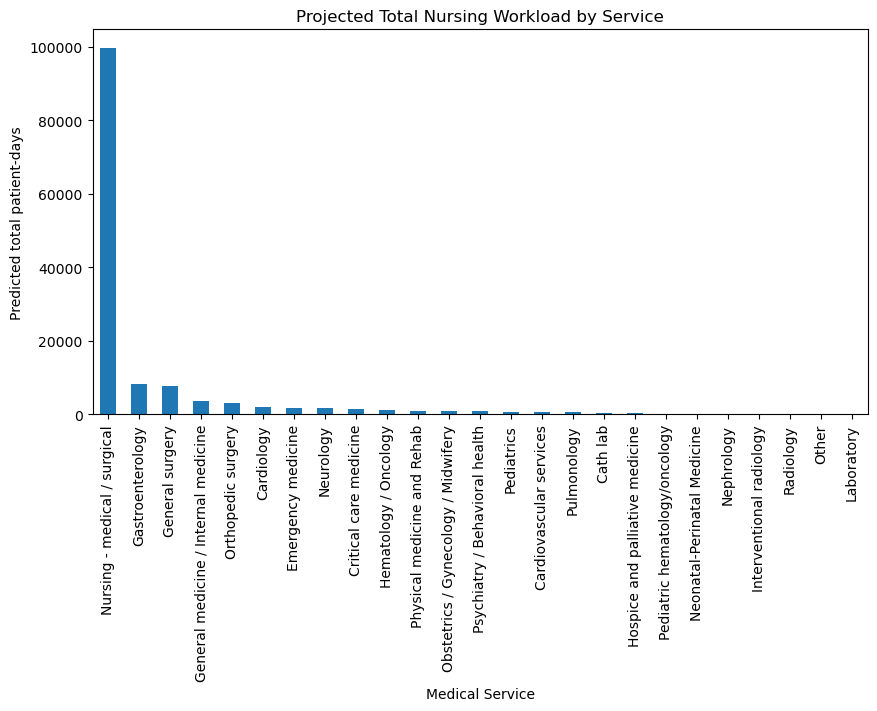

In [48]:
import matplotlib.pyplot as plt
workload_projection["Total_workload_days"].plot(kind="bar", figsize=(10,5))
plt.title("Projected Total Nursing Workload by Service")
plt.ylabel("Predicted total patient-days")
plt.xlabel("Medical Service")
plt.show()
